# Predicting Financial Stress Events with the Disaggregate Sub-Indices.

In [ ]:
SEED = 23
# --- ENV FIRST ---
import os
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"
# --- IMPORTS ---
import random
import numpy as np
import tensorflow as tf
# --- TF CONFIG ---
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.set_visible_devices([], 'GPU')
# --- SEEDS ---
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
# --- RESET ---
tf.keras.backend.clear_session()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import recall_score, f1_score, roc_auc_score, confusion_matrix, accuracy_score, roc_curve
import itertools
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers
try:
  import keras_tuner as kt
except:
  !pip install keras-tuner
  import keras_tuner as kt
from google.colab import files
from google.colab import drive
import pandas as pd
import io
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 894.6 kB/s eta 0:00:00


In [ ]:
def import_data(file_path):
  try:
    drive.mount('/content/drive', force_remount=True)
    # Check if file exists
    if os.path.exists(file_path):
      df = pd.read_parquet(file_path)
      print(f"Loaded dataframe from Drive ({file_path})")
    else:
      raise FileNotFoundError(f"File not found at {file_path}")

  except Exception as e:
    print(f"Drive not available or file missing: {e}")
    print("Please upload dataframe manually.")
    uploaded = files.upload()

    # Automatically read the uploaded file
    file_name = list(uploaded.keys())[0]  # pick the first uploaded file
    try:
      df = pd.read_parquet(io.BytesIO(uploaded[file_name]))
    except:
      print("Wrong file extension. Parquet file required.")
    print(f"Loaded {file_name} from manual upload.")
    return df

In [ ]:
file_path = "..."
risk_ecdf = import_data(file_path)

Drive not available or file missing: Error: credential propagation was unsuccessful
Please upload dataframe manually.


Saving risk_ecdf.parquet to risk_ecdf.parquet
Loaded risk_ecdf.parquet from manual upload.


In [ ]:
risk_ecdf

,VGCI,VMFI,VFTI,VTRI,VMII
2016-01-06,0.362550,0.298805,0.243028,0.007968,0.434263
2016-01-07,0.386454,0.318725,0.557769,0.007968,0.434263
2016-01-08,0.314741,0.326693,0.087649,0.003984,0.434263
2016-01-11,0.434263,0.330677,0.203187,0.007968,0.398406
2016-01-12,0.294821,0.342629,0.609562,0.003984,0.414343
...,...,...,...,...,...
2026-03-25,0.003984,0.996016,0.282869,0.996016,0.370518
2026-03-26,0.003984,0.996016,0.370518,0.996016,0.378486
2026-03-27,0.003984,0.996016,0.278884,0.988048,0.398406
2026-03-30,0.007968,0.992032,0.211155,0.996016,0.402390


In [ ]:
df_sse = import_data(file_path)

Drive not available or file missing: Error: credential propagation was unsuccessful
Please upload dataframe manually.


Saving df_sse.parquet to df_sse.parquet
Loaded df_sse.parquet from manual upload.


In [ ]:
# build a dataframe with the 5 disaggregate indicators (predictors) and the Systemic Stress Events variable (target)
df_bench = pd.concat([risk_ecdf, df_sse['systemic_stress_event']], axis=1, join='inner').dropna()
# align the dataframe at the same starting date of the VSRI
df_bench = df_bench.loc['2017-01-03':].dropna()

In [ ]:
df_bench.shape

(2285, 6)

In [ ]:
# split data in training and test set and apply purging
split_date = "2024-03-31"
purge = 20
train_bench = df_bench.loc[:split_date].iloc[:-purge]
test_bench  = df_bench[df_bench.index > split_date]

X_train_bench = train_bench[["VGCI",	"VMFI",	"VFTI",	"VTRI",	"VMII"]]
y_train_bench = train_bench["systemic_stress_event"]
X_test_bench  = test_bench[["VGCI",	"VMFI",	"VFTI",	"VTRI",	"VMII"]]
y_test_bench  = test_bench["systemic_stress_event"]

In [ ]:
print(X_train_bench.shape, y_train_bench.shape, X_test_bench.shape, y_test_bench.shape)

(1789, 5) (1789,) (476, 5) (476,)


In [ ]:
y_train_bench.value_counts()

,count
systemic_stress_event,
0,1663
1,126


In [ ]:
y_test_bench.value_counts()

,count
systemic_stress_event,
0,452
1,24


In [ ]:
def train_classifier(model, X_train, y_train, X_test, y_test, X_val=False, y_val=False, threshold=0.5, early_stopping=False):
  is_keras = hasattr(model, "fit") and hasattr(model, "predict") and not hasattr(model, "predict_proba")
  if is_keras:
    if early_stopping:
      model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, class_weight=class_weight, validation_data=(X_val, y_val), shuffle=False, callbacks=[combined_metric, es])
    else:
      model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, class_weight=class_weight, validation_data=(X_val, y_val), shuffle=False)
    y_score = model.predict(X_test).ravel()
    y_pred = (y_score >= threshold).astype(int)
  else:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

  # Output Following Metrics:
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  roc_auc = roc_auc_score(y_test, y_score)
  cm = confusion_matrix(y_test, y_pred)

  return recall, f1, roc_auc, cm, y_score, y_pred

In [ ]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
    print('Confusion matrix, without normalization')

  print(cm)
  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes)#, rotation=45)
  plt.yticks(tick_marks, classes)
  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')

## 5.1. Logistic Regression.

In [ ]:
lr_model_bench = LogisticRegression(class_weight="balanced")
lr_results_bench = train_classifier(lr_model_bench, X_train_bench, y_train_bench, X_test_bench, y_test_bench)

In [ ]:
lr_recall_bench, lr_f1_bench, lr_roc_auc_bench, lr_cm_bench, lr_probs_bench, lr_preds_bench = lr_results_bench

Confusion matrix, without normalization
[[192 260]
 [  1  23]]


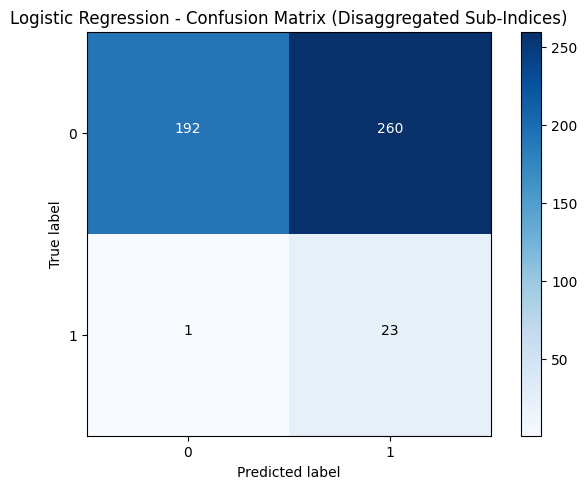

In [ ]:
plot_confusion_matrix(cm=lr_cm_bench, classes=[0,1], normalize= False,  title='Logistic Regression - Confusion Matrix (Disaggregated Sub-Indices)')

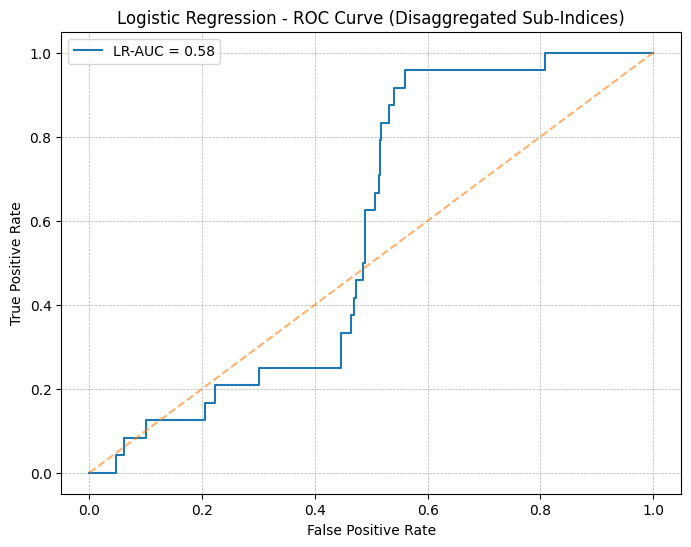

In [ ]:
fpr, tpr, thr = roc_curve(y_test_bench, lr_probs_bench)
# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"LR-AUC = {lr_roc_auc_bench:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.6)  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve (Disaggregated Sub-Indices)")
plt.legend()
plt.grid(True, linestyle='--', linewidth=.5)
plt.show()

In [ ]:
lr_results_bench = {'Recall': lr_recall_bench, 'F1-Score': lr_f1_bench, 'ROC-AUC': lr_roc_auc_bench}
lr_results_bench_df = pd.DataFrame(lr_results_bench, index=['Logistic Regression (Disaggregated Sub-Indices)'])
lr_results_bench_df

,Recall,F1-Score,ROC-AUC
Logistic Regression (Disaggregated Sub-Indices),0.958333,0.149837,0.575129


## 5.2. Support Vector Machines.

Confusion matrix, without normalization
[[264 188]
 [ 17   7]]


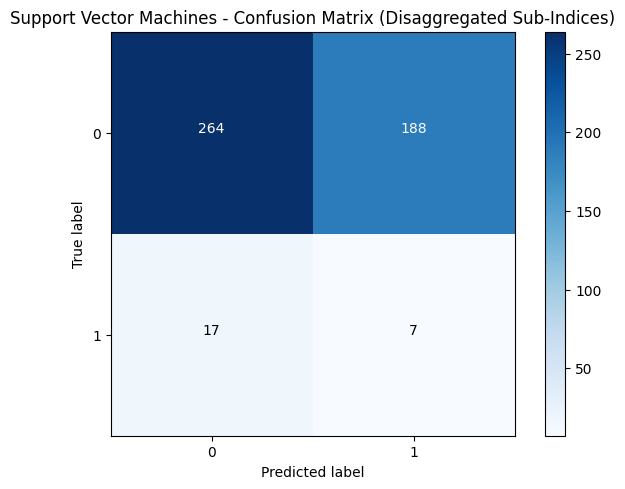

In [ ]:
svm_model_bench = SVC(C=0.5, kernel='rbf', probability=True, class_weight="balanced")
svm_results_bench = train_classifier(svm_model_bench, X_train_bench, y_train_bench, X_test_bench, y_test_bench)
svm_recall_bench, svm_f1_bench, svm_roc_auc_bench, svm_cm_bench, svm_probs_bench, svm_preds_bench = svm_results_bench
plot_confusion_matrix(cm=svm_cm_bench, classes=[0,1], normalize= False,  title='Support Vector Machines - Confusion Matrix (Disaggregated Sub-Indices)')

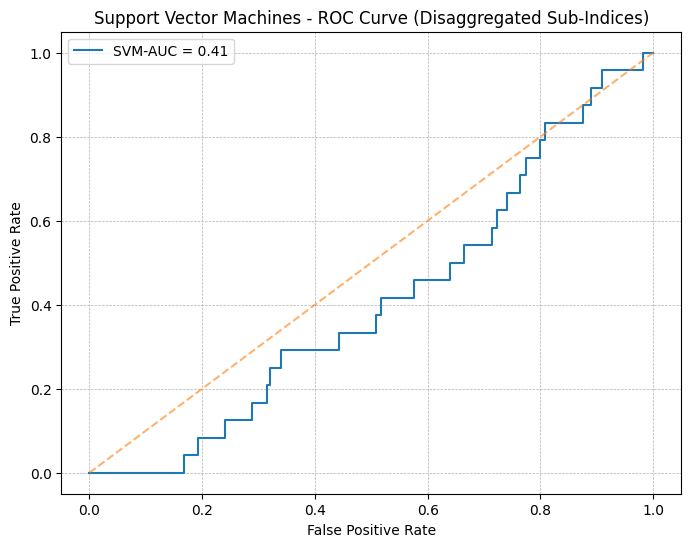

In [ ]:
fpr, tpr, thr = roc_curve(y_test_bench, svm_probs_bench)
# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"SVM-AUC = {svm_roc_auc_bench:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.6)  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Support Vector Machines - ROC Curve (Disaggregated Sub-Indices)")
plt.legend()
plt.grid(True, linestyle='--', linewidth=.5)
plt.show()

In [ ]:
svm_results_bench = pd.DataFrame({'Recall': svm_recall_bench, 'F1-Score': svm_f1_bench, 'ROC-AUC': svm_roc_auc_bench},index=['Support Vector Machines (Disaggregated Sub-Indices)'])
svm_results_bench

,Recall,F1-Score,ROC-AUC
Support Vector Machines (Disaggregated Sub-Indices),0.291667,0.063927,0.408647


## 5.3. Long Short-Term Memory (LSTM) Networks.

In [ ]:
timesteps = 60
split_idx = pd.Timestamp("2023-03-01")
X_train_lstm_bench = X_train_bench[X_train_bench.index < split_idx].iloc[:-purge]
y_train_lstm_bench = y_train_bench[y_train_bench.index < split_idx].iloc[:-purge]
X_val_lstm_bench = X_train_bench.loc[split_idx:]
y_val_lstm_bench = y_train_bench.loc[split_idx:]

X_train_values_bench = X_train_lstm_bench.values
y_train_values_bench = y_train_lstm_bench.values
X_test_values_bench = X_test_bench.values
y_test_values_bench = y_test_bench.values
X_val_values_bench = X_val_lstm_bench.values
y_val_values_bench = y_val_lstm_bench.values
X_train_seq_bench = []
y_train_seq_bench = []
X_test_seq_bench = []
y_test_seq_bench = []
X_val_seq_bench = []
y_val_seq_bench = []
for i in range(timesteps, len(X_train_values_bench)):
  X_train_seq_bench.append(X_train_values_bench[i - timesteps:i])
  y_train_seq_bench.append(y_train_values_bench[i])
for i in range(timesteps, len(X_test_values_bench)):
  X_test_seq_bench.append(X_test_values_bench[i - timesteps:i])
  y_test_seq_bench.append(y_test_values_bench[i])
for i in range(timesteps, len(X_val_values_bench)):
  X_val_seq_bench.append(X_val_values_bench[i - timesteps:i])
  y_val_seq_bench.append(y_val_values_bench[i])

X_train_seq_bench = np.array(X_train_seq_bench)
y_train_seq_bench = np.array(y_train_seq_bench)
X_test_seq_bench = np.array(X_test_seq_bench)
y_test_seq_bench = np.array(y_test_seq_bench)
X_val_seq_bench = np.array(X_val_seq_bench)
y_val_seq_bench = np.array(y_val_seq_bench)

In [ ]:
print(X_train_seq_bench.shape,
      y_train_seq_bench.shape,
      X_val_seq_bench.shape,
      y_val_seq_bench.shape,
      X_test_seq_bench.shape,
      y_test_seq_bench.shape)

(1457, 60, 5) (1457,) (192, 60, 5) (192,) (416, 60, 5) (416,)


In [ ]:
np.unique(y_train_seq_bench, return_counts=True)

(array([0, 1]), array([1341,  116]))

In [ ]:
np.unique(y_val_seq_bench, return_counts=True)

(array([0, 1]), array([182,  10]))

In [ ]:
np.unique(y_test_seq_bench, return_counts=True)

(array([0, 1]), array([392,  24]))

In [ ]:
tf.keras.backend.clear_session()
input_shape = X_train_seq_bench.shape[1:]  # (60, num_features)
lstm_model_bench = keras.Sequential()
lstm_model_bench.add(layers.LSTM(128, return_sequences=True, input_shape=input_shape))
lstm_model_bench.add(layers.Dropout(0.5))
lstm_model_bench.add(layers.LSTM(128, return_sequences=True))
lstm_model_bench.add(layers.LSTM(16, return_sequences=True))
lstm_model_bench.add(layers.LSTM(8, return_sequences=True))
lstm_model_bench.add(layers.Dropout(0.3))
lstm_model_bench.add(layers.LSTM(8, return_sequences=False))
lstm_model_bench.add(layers.Dropout(0.3))
# Dense layers
lstm_model_bench.add(layers.Dense(16, activation="relu"))
lstm_model_bench.add(layers.Dense(1, activation="sigmoid"))
# Compile
lstm_model_bench.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="pr_auc", curve="PR"),
        keras.metrics.AUC(name="roc_auc", curve="ROC"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision")])

lstm_model_bench.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 16)         │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 8)          │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,977 (824.13 KB)

 Trainable params: 210,977 (824.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class CombinedMetric(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    logs = logs or {}
    recall = logs.get("val_recall", 0)
    pr_auc = logs.get("val_pr_auc", 0)
    logs["val_combined"] = 0.3 * recall + 0.7 * pr_auc

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
combined_metric = CombinedMetric()
es = tf.keras.callbacks.EarlyStopping(monitor="val_combined", mode="max", patience=50, restore_best_weights=True, verbose=1)
classes = np.unique(y_train_seq_bench)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_seq_bench)
class_weight = dict(zip(classes, weights))
epochs=200
batch_size=32

lstm_results_bench = train_classifier(lstm_model_bench, X_train_seq_bench, y_train_seq_bench, X_test_seq_bench, y_test_seq_bench, X_val=X_val_seq_bench, y_val=y_val_seq_bench, early_stopping=True)

Epoch 1/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 213ms/step - loss: 0.6959 - pr_auc: 0.0579 - precision: 0.0373 - recall: 0.1552 - roc_auc: 0.3728 - val_loss: 0.6937 - val_pr_auc: 0.0521 - val_precision: 0.0562 - val_recall: 1.0000 - val_roc_auc: 0.5000 - val_combined: 0.3365
Epoch 2/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 213ms/step - loss: 0.6925 - pr_auc: 0.0804 - precision: 0.0904 - recall: 0.4224 - roc_auc: 0.5243 - val_loss: 0.6950 - val_pr_auc: 0.0521 - val_precision: 0.0521 - val_recall: 1.0000 - val_roc_auc: 0.5000 - val_combined: 0.3365
Epoch 3/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 214ms/step - loss: 0.6944 - pr_auc: 0.0775 - precision: 0.0758 - recall: 0.4741 - roc_auc: 0.4756 - val_loss: 0.6943 - val_pr_auc: 0.0521 - val_precision: 0.0847 - val_recall: 1.0000 - val_roc_auc: 0.5000 - val_combined: 0.3365
Epoch 4/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 202ms/step - loss: 0.6939 - pr_auc: 0.0765 - precision: 0.0877 - recall: 0.3017 - roc_auc: 0.4860 - val_loss: 0.6825 - val_pr_auc: 0.0814 - val_p

In [ ]:
lstm_recall_bench, lstm_f1_bench, lstm_roc_auc_bench, lstm_cm_bench, lstm_probs_bench, lstm_preds_bench = lstm_results_bench

Confusion matrix, without normalization
[[369  23]
 [ 24   0]]


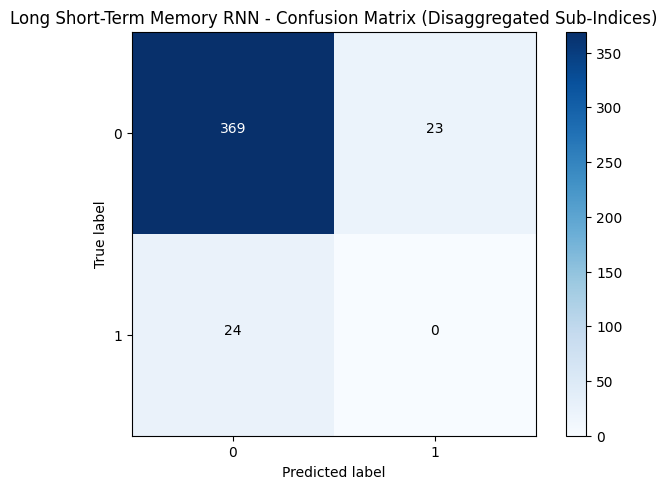

In [ ]:
plot_confusion_matrix(cm=lstm_cm_bench, classes=[0,1], normalize= False,  title='Long Short-Term Memory RNN - Confusion Matrix (Disaggregated Sub-Indices)')

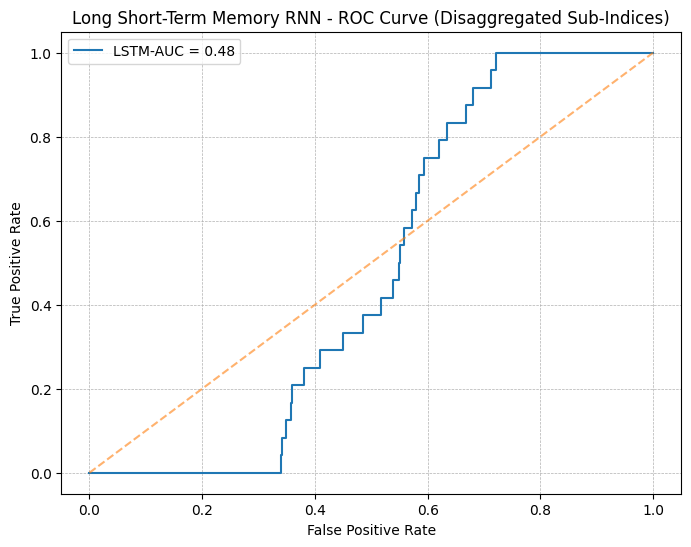

In [ ]:
fpr, tpr, thr = roc_curve(y_test_seq_bench, lstm_probs_bench)
# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"LSTM-AUC = {lstm_roc_auc_bench:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.6)  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Long Short-Term Memory RNN - ROC Curve (Disaggregated Sub-Indices)")
plt.legend()
plt.grid(True, linestyle='--', linewidth=.5)
plt.show()

In [ ]:
lstm_results_bench = pd.DataFrame({'Recall': lstm_recall_bench, 'F1-Score': lstm_f1_bench, 'ROC-AUC': lstm_roc_auc_bench},index=['Long Short-Term Memory RNN (Disaggregated Sub-Indices)'])
ml_results_bench = pd.concat([lr_results_bench_df.round(2), svm_results_bench.round(2), lstm_results_bench.round(2)])
ml_results_bench

,Recall,F1-Score,ROC-AUC
Logistic Regression (Disaggregated Sub-Indices),0.96,0.15,0.58
Support Vector Machines (Disaggregated Sub-Indices),0.29,0.06,0.41
Long Short-Term Memory RNN (Disaggregated Sub-Indices),0.00,0.00,0.48


```python
ml_results_bench.to_csv("ml_results_bench.csv", index=True)
files.download("ml_results_bench.csv")
ml_results_bench.to_parquet("ml_results_bench.parquet", index=True)
files.download("ml_results_bench.parquet")
```